In [23]:
# Operações Numéricas
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Redes Neurais
import tensorflow as tf

# Redes Neurais - Alto Nível
from tensorflow import keras

# Camadas de Rede e Pré-processamento
from tensorflow.keras.layers import (
    Conv2D,
    Input,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomTranslation
)

# Callbacks para Otimização do Treinamento
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Métricas de Avaliação
from sklearn.metrics import confusion_matrix, classification_report

# Bibliotecas de Imagem
from tensorflow.keras.utils import load_img, img_to_array

# Carregar base CIFAR-10

In [24]:
# Carregar base CIFAR

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalizar valores para o intervalo [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# y vem como coluna
y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = [
    'avião',
    'automóvel',
    'pássaro',
    'gato',
    'cervo',
    'cachorro',
    'sapo',
    'cavalo',
    'navio',
    'caminhão'
]

print(f"Formato de x_train: ", x_train.shape)
print(f"Formato de y_train: ", y_train.shape)
print(f"Formato de x_test: ", x_test.shape)
print(f"Formato de y_test: ", y_test.shape)

Formato de x_train:  (50000, 32, 32, 3)
Formato de y_train:  (50000,)
Formato de x_test:  (10000, 32, 32, 3)
Formato de y_test:  (10000,)


# Plotar Algumas Imagens

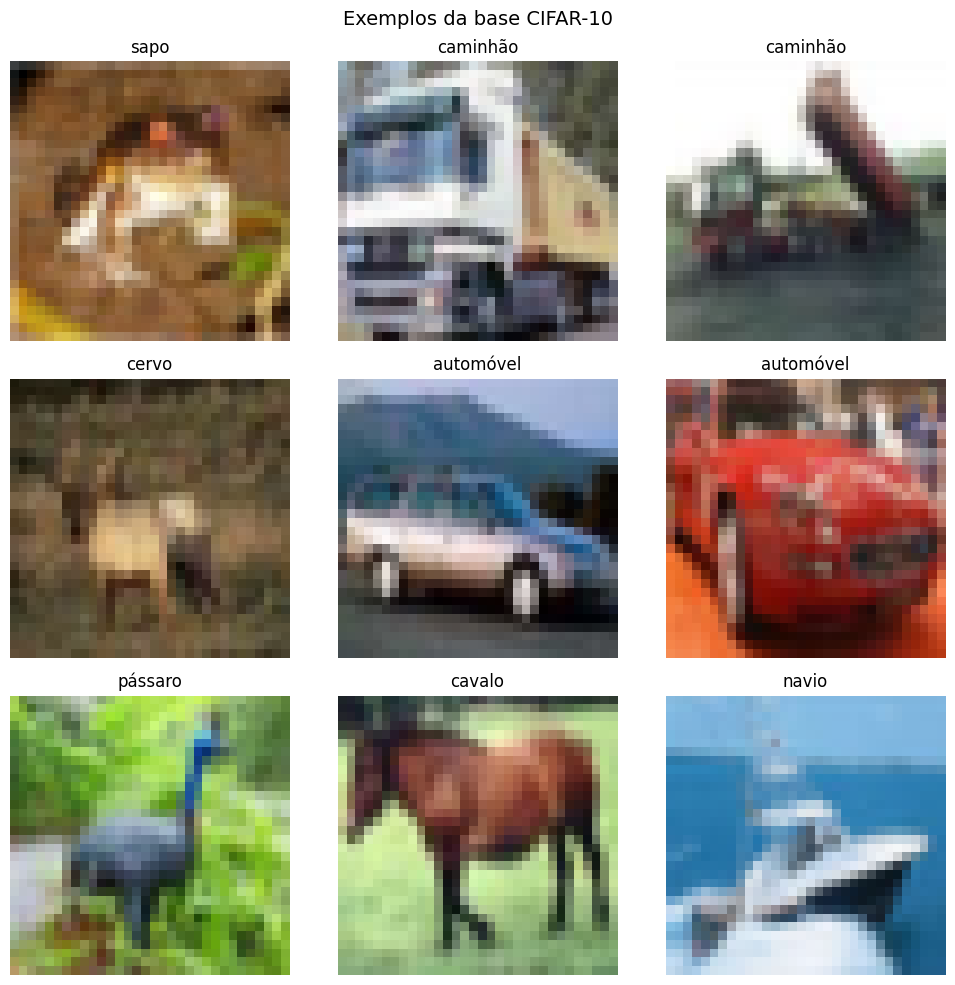

In [25]:
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)                # divide o plot em 3 linhas e 3 colunas
    plt.imshow(x_train[i])                  # carrega a imagem na posição i
    plt.title(class_names[y_train[i]])      # pega o nome da classe referente
    plt.axis('off')                         # remove os eixos
plt.suptitle("Exemplos da base CIFAR-10", fontsize=14)   # define o subtítulo do gráfico
plt.tight_layout()                          # remove espaços não usados
plt.show()                                  # exibe a imagem

# Criação do Modelo CNN Otimizado

Para elevar substancialmente a acurácia no CIFAR-10 (passando da faixa de ~65% para mais de 80-86%), implementamos as seguintes melhorias:
1. **Data Augmentation Integrado**: Geração dinâmica de variações durante o treino (espelhamento horizontal, pequenas rotações, zoom e translações) para prevenir overfitting e aumentar a capacidade de generalização.
2. **Arquitetura VGG-Style (Blocos Convolucionais Duplos)**: Cada estágio possui 2 camadas de convolução consecutivas com `padding='same'`, preservando resolução espacial e extraindo representações visuais mais profundas.
3. **Batch Normalization**: Normalização em lote após cada convolução e camada densa para acelerar a convergência e estabilizar os gradientes.
4. **Dropout Progressivo**: Taxas de regularização graduais (0.2 -> 0.3 -> 0.4 -> 0.5) evitando que neurônios co-adaptem e promovendo robustez.
5. **Classificador Denso Otimizado**: Camada de 128 neurônios com Batch Normalization e Dropout antes da camada final Softmax.

In [26]:
model = keras.Sequential()

# Camada de Entrada
model.add(Input(shape=(32, 32, 3)))

# 1. Data Augmentation (ativo automaticamente apenas no treino)
model.add(RandomFlip("horizontal"))
model.add(RandomRotation(0.08))
model.add(RandomTranslation(0.08, 0.08))
model.add(RandomZoom(0.08))

# 2. Bloco Convolucional 1 (32 filtros)
model.add(Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters=32, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

# 3. Bloco Convolucional 2 (64 filtros)
model.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.3))

# 4. Bloco Convolucional 3 (128 filtros)
model.add(Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.4))

# 5. Classificador Totalmente Conectado (Dense Head)
model.add(Flatten())
model.add(Dense(units=128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(units=len(class_names), activation='softmax'))

# Compilação do Modelo com Adam
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Resumo do Modelo
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             

 Total params: 552,874 (2.11 MB)

 Trainable params: 551,722 (2.10 MB)

 Non-trainable params: 1,152 (4.50 KB)

# Treinar a Rede com Callbacks Dinâmicos

Utilizamos dois callbacks essenciais para maximizar o desempenho:
- `ReduceLROnPlateau`: Reduz a taxa de aprendizado em 50% se a perda de validação (`val_loss`) não melhorar por 3 épocas consecutivas, permitindo que os pesos atinjam um mínimo mais preciso.
- `EarlyStopping`: Interrompe o treinamento caso não haja melhora por 7 épocas consecutivas e restaura automaticamente os pesos com melhor desempenho em validação (`restore_best_weights=True`).

In [27]:
# Callbacks para controle dinâmico do treino
callbacks = [
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=7,
        restore_best_weights=True,
        verbose=1
    )
]

# Treinamento da Rede
history = model.fit(
    x_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 22ms/step - accuracy: 0.3438 - loss: 1.9234 - val_accuracy: 0.4864 - val_loss: 1.4418 - learning_rate: 0.0010
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.4810 - loss: 1.4413 - val_accuracy: 0.4997 - val_loss: 1.5452 - learning_rate: 0.0010
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.5419 - loss: 1.2831 - val_accuracy: 0.5923 - val_loss: 1.1512 - learning_rate: 0.0010
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.5817 - loss: 1.1737 - val_accuracy: 0.6155 - val_loss: 1.1518 - learning_rate: 0.0010
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.6109 - loss: 1.1006 - val_accuracy: 0.6019 - val_loss: 1.2273 - learning_rate: 0.0010
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.6409 - loss: 1.0242 - val_accuracy: 0.6555 - val_loss: 0.9903 - learning_rate: 0.0010
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.6588 - l

# Plot da Acurácia e do Loss

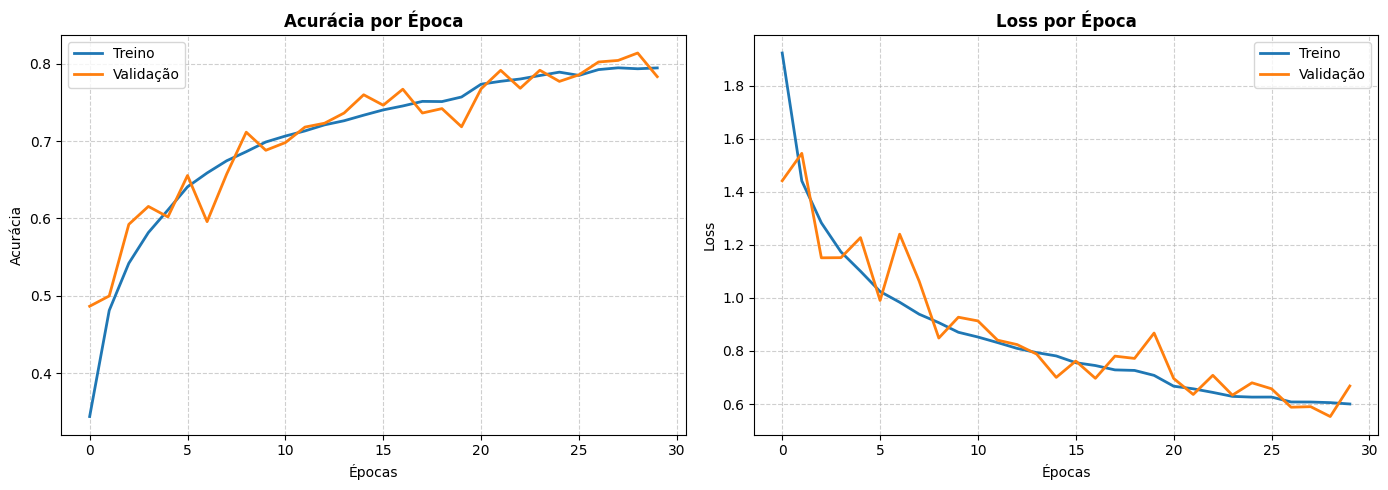

In [28]:
plt.figure(figsize=(14, 5))

# Gráfico de Acurácia
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label="Treino", linewidth=2)
plt.plot(history.history['val_accuracy'], label="Validação", linewidth=2)
plt.title("Acurácia por Época", fontsize=12, fontweight='bold')
plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

# Gráfico de Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label="Treino", linewidth=2)
plt.plot(history.history['val_loss'], label="Validação", linewidth=2)
plt.title("Loss por Época", fontsize=12, fontweight='bold')
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

# Avaliação no Conjunto de Teste

In [29]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=1)
print(f'\nAcurácia do conjunto de teste: {(test_acc * 100):.2f}%')
print(f'Loss do teste: {test_loss:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8140 - loss: 0.5715

Acurácia do conjunto de teste: 81.40%
Loss do teste: 0.5715


# Matriz de Confusão e Relatório de Classificação

A matriz de confusão e o relatório de classificação fornecem a avaliação completa do classificador em todo o conjunto de teste (10.000 imagens), permitindo verificar quais classes obtiveram melhor precisão/recall e onde ocorreram confusões (ex: classes visualmente similares como gato vs cachorro).

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


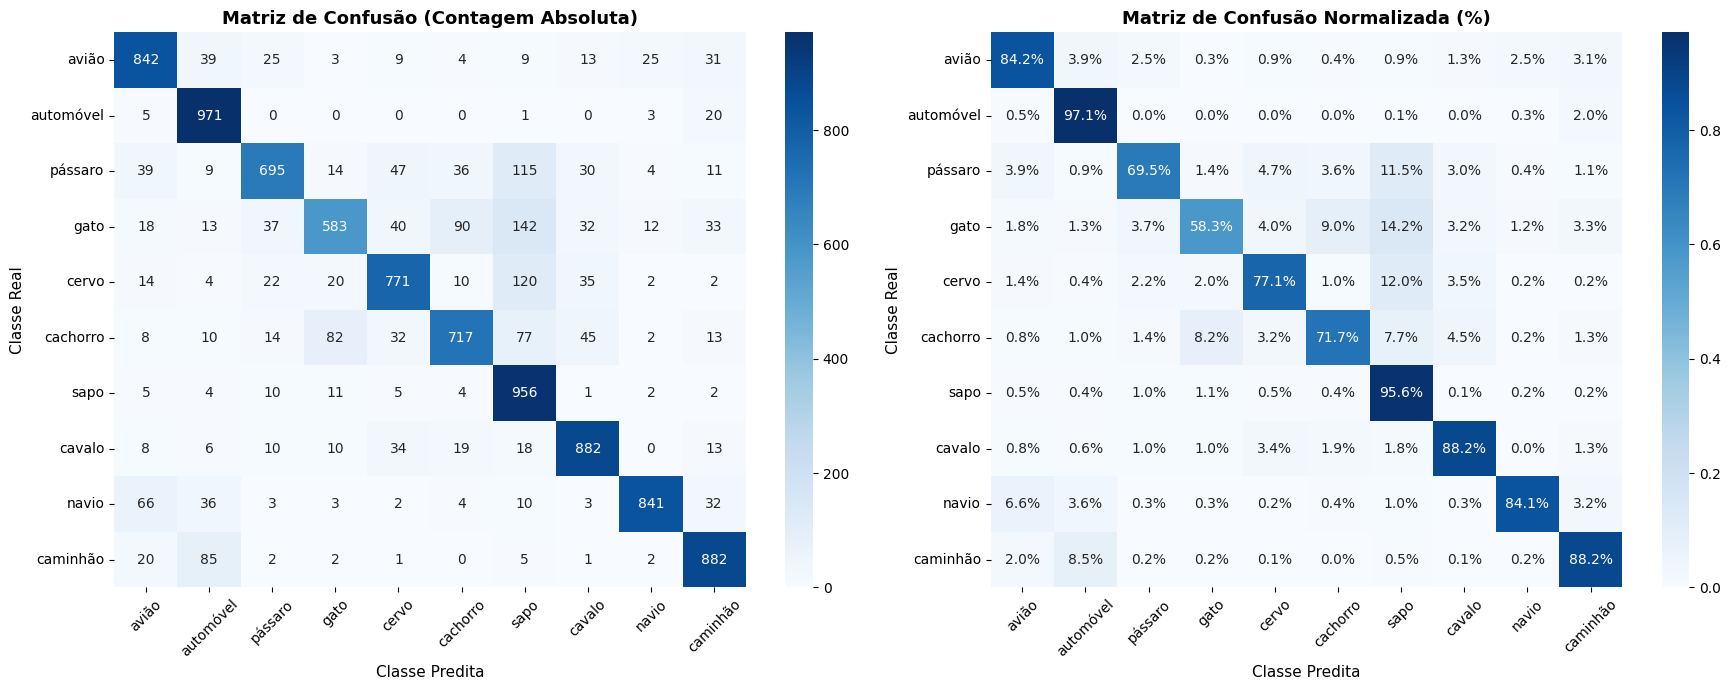


--- Relatório de Classificação por Classe ---
              precision    recall  f1-score   support

       avião      0.821     0.842     0.832      1000
   automóvel      0.825     0.971     0.892      1000
     pássaro      0.850     0.695     0.765      1000
        gato      0.801     0.583     0.675      1000
       cervo      0.819     0.771     0.794      1000
    cachorro      0.811     0.717     0.761      1000
        sapo      0.658     0.956     0.779      1000
      cavalo      0.846     0.882     0.864      1000
       navio      0.942     0.841     0.889      1000
    caminhão      0.849     0.882     0.865      1000

    accuracy                          0.814     10000
   macro avg      0.822     0.814     0.812     10000
weighted avg      0.822     0.814     0.812     10000



In [30]:
# Predições para todo o conjunto de teste
y_pred_probs = model.predict(x_test, batch_size=64)
y_pred = np.argmax(y_pred_probs, axis=1)

# Cálculo da Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)

# Plotando as Matrizes de Confusão (Absoluta e Normalizada lado a lado)
fig, ax = plt.subplots(1, 2, figsize=(18, 7))

# 1. Contagens Absolutas
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax[0]
)
ax[0].set_title('Matriz de Confusão (Contagem Absoluta)', fontsize=13, fontweight='bold')
ax[0].set_xlabel('Classe Predita', fontsize=11)
ax[0].set_ylabel('Classe Real', fontsize=11)
ax[0].tick_params(axis='x', rotation=45)

# 2. Normalizada (% de acerto por classe real)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.1%',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax[1]
)
ax[1].set_title('Matriz de Confusão Normalizada (%)', fontsize=13, fontweight='bold')
ax[1].set_xlabel('Classe Predita', fontsize=11)
ax[1].set_ylabel('Classe Real', fontsize=11)
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Relatório Detalhado com Precisão, Recall e F1-Score
print("\n--- Relatório de Classificação por Classe ---")
print(classification_report(y_test, y_pred, target_names=class_names, digits=3))

# Previsões em Imagens do Teste

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step


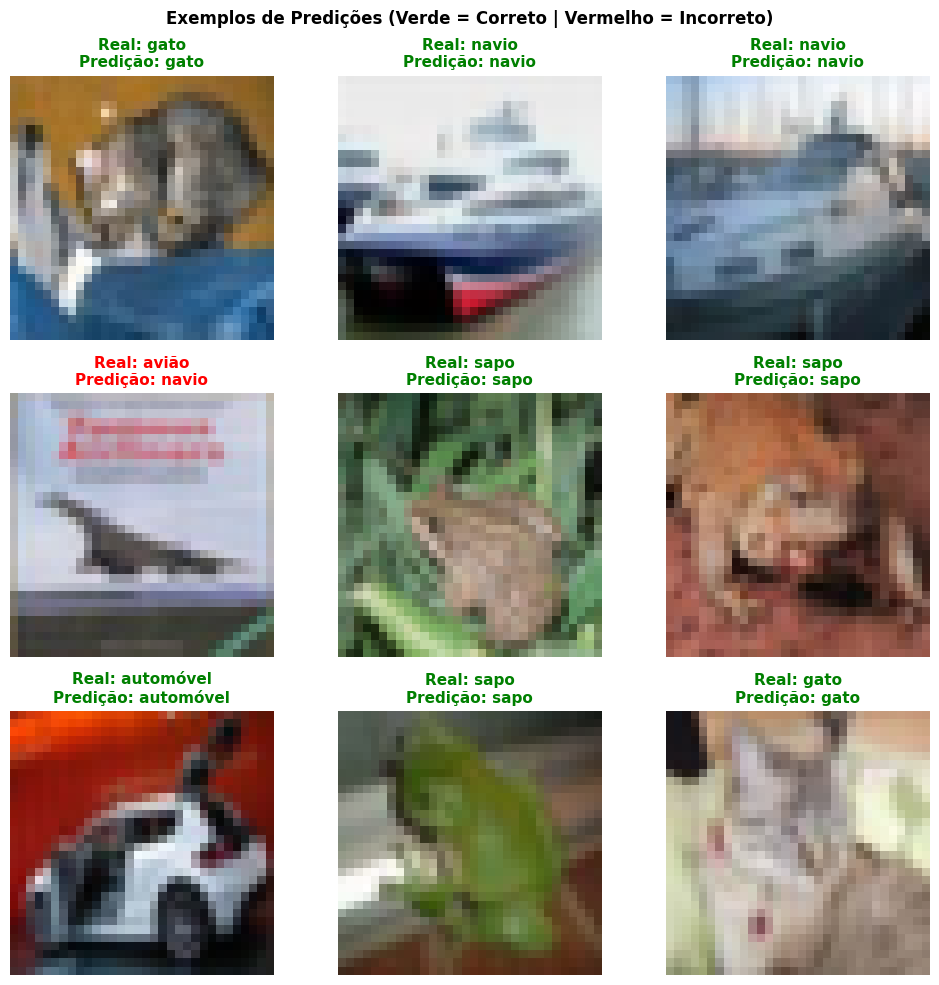

In [31]:
# Visualização das primeiras 9 imagens do teste com rótulo real vs predito
pred_probs_sample = model.predict(x_test[:9])
pred_labels_sample = np.argmax(pred_probs_sample, axis=1)

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[i])
    real = class_names[y_test[i]]
    pred = class_names[pred_labels_sample[i]]
    
    # Destaca verde se acertou, vermelho se errou
    cor = 'green' if real == pred else 'red'
    plt.title(f"Real: {real}\nPredição: {pred}", color=cor, fontsize=11, fontweight='bold')
    plt.axis('off')

plt.suptitle('Exemplos de Predições (Verde = Correto | Vermelho = Incorreto)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()